Failed to download (trying next):
HTTP Error 403: Forbidden



100%|██████████| 9.91M/9.91M [00:00<00:00, 17.9MB/s]


Extracting ./data/MNIST/raw/train-images-idx3-ubyte.gz to ./data/MNIST/raw

Failed to download (trying next):
HTTP Error 403: Forbidden



100%|██████████| 28.9k/28.9k [00:00<00:00, 484kB/s]


Extracting ./data/MNIST/raw/train-labels-idx1-ubyte.gz to ./data/MNIST/raw

Failed to download (trying next):
HTTP Error 403: Forbidden



100%|██████████| 1.65M/1.65M [00:00<00:00, 4.49MB/s]


Extracting ./data/MNIST/raw/t10k-images-idx3-ubyte.gz to ./data/MNIST/raw

Failed to download (trying next):
HTTP Error 403: Forbidden



100%|██████████| 4.54k/4.54k [00:00<00:00, 11.6MB/s]


Extracting ./data/MNIST/raw/t10k-labels-idx1-ubyte.gz to ./data/MNIST/raw

Epoch [1/5], Loss: 1.0005
Epoch [2/5], Loss: 1.0001
Epoch [3/5], Loss: 1.0001
Epoch [4/5], Loss: 1.0001
Epoch [5/5], Loss: 1.0001


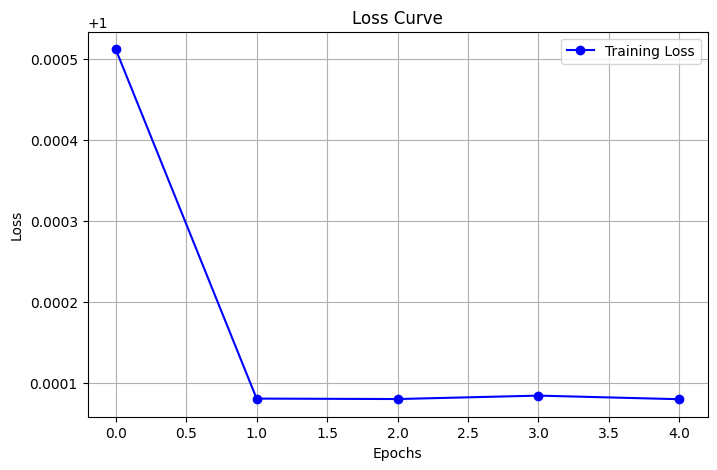

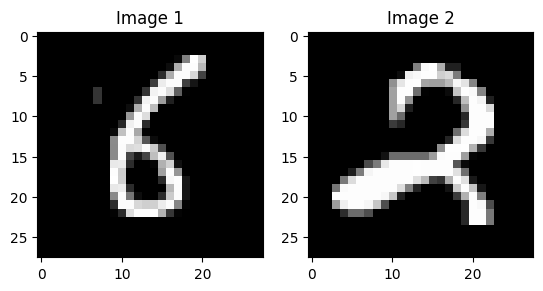

Similarity Score: 0.0001


In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt
from torchvision import datasets, transforms
from torch.utils.data import DataLoader

# 1. تعریف شبکه سیامی
class SiameseNetwork(nn.Module):
    def __init__(self):
        super(SiameseNetwork, self).__init__()
        self.conv = nn.Sequential(
            nn.Conv2d(1, 64, kernel_size=5),
            nn.ReLU(),
            nn.MaxPool2d(2, 2),
            nn.Conv2d(64, 128, kernel_size=5),
            nn.ReLU(),
            nn.MaxPool2d(2, 2),
        )
        self.fc = nn.Sequential(
            nn.Linear(128 * 4 * 4, 256),
            nn.ReLU(),
            nn.Linear(256, 128),
        )

    def forward_one(self, x):
        x = self.conv(x)
        x = x.view(x.size(0), -1)
        x = self.fc(x)
        return x

    def forward(self, x1, x2):
        out1 = self.forward_one(x1)
        out2 = self.forward_one(x2)
        return out1, out2

# 2. تعریف تابع فاصله اقلیدسی
def euclidean_distance(x1, x2):
    return torch.sqrt(torch.sum((x1 - x2) ** 2, dim=1) + 1e-8)

# 3. آماده‌سازی داده‌ها
transform = transforms.Compose([transforms.ToTensor()])
train_data = datasets.MNIST(root='./data', train=True, download=True, transform=transform)
train_loader = DataLoader(train_data, shuffle=True, batch_size=32)

# 4. متا-یادگیری: پشتیبانی و آزمون
def meta_learning_training(model, loader, optimizer, criterion, epochs=5):
    model.train()
    loss_history = []  # ذخیره مقادیر Loss برای رسم نمودار
    for epoch in range(epochs):
        epoch_loss = 0  # جمع کل Loss برای هر دوره
        for i, (images, labels) in enumerate(loader):
            img1, img2 = images[:16], images[16:32]
            label1, label2 = labels[:16], labels[16:32]

            # ایجاد هدف (target): مشابه (1) یا متفاوت (-1)
            target = torch.tensor([1 if label1[i] == label2[i] else -1 for i in range(len(label1))], dtype=torch.float32)
            target = target.to(img1.device)

            optimizer.zero_grad()
            out1, out2 = model(img1, img2)
            distance = euclidean_distance(out1, out2)

            # محاسبه Loss
            loss = criterion(distance, torch.zeros_like(distance), target)
            loss.backward()
            optimizer.step()
            epoch_loss += loss.item()

        avg_loss = epoch_loss / len(loader)  # میانگین Loss در هر دوره
        loss_history.append(avg_loss)
        print(f"Epoch [{epoch + 1}/{epochs}], Loss: {avg_loss:.4f}")

    return loss_history

# 5. رسم تصاویر، نمودار شباهت و نمودار Loss
def plot_loss_curve(loss_history):
    plt.figure(figsize=(8, 5))
    plt.plot(loss_history, label="Training Loss", color='blue', marker='o')
    plt.title("Loss Curve")
    plt.xlabel("Epochs")
    plt.ylabel("Loss")
    plt.legend()
    plt.grid()
    plt.show()

def plot_images_and_similarity(model, loader):
    model.eval()
    data_iter = iter(loader)
    images, labels = next(data_iter)
    img1, img2 = images[:1], images[1:2]

    with torch.no_grad():
        out1, out2 = model(img1, img2)
        similarity = euclidean_distance(out1, out2).item()

    # نمایش تصاویر
    fig, ax = plt.subplots(1, 2)
    ax[0].imshow(img1[0].squeeze(), cmap='gray')
    ax[0].set_title("Image 1")
    ax[1].imshow(img2[0].squeeze(), cmap='gray')
    ax[1].set_title("Image 2")
    plt.show()

    # نمایش شباهت
    print(f"Similarity Score: {similarity:.4f}")

# 6. آموزش مدل و نمایش نتایج
model = SiameseNetwork()
optimizer = optim.Adam(model.parameters(), lr=0.001)
criterion = nn.MarginRankingLoss(margin=1.0)  # تعریف loss با حاشیه (margin)

# آموزش مدل و ذخیره مقادیر Loss
loss_history = meta_learning_training(model, train_loader, optimizer, criterion)

# رسم نمودار Loss
plot_loss_curve(loss_history)

# نمایش نتایج شباهت
plot_images_and_similarity(model, train_loader)
